## Translating Between Tokenizers

In [1]:
import tiktoken
from transformers import BertTokenizer
import matplotlib.pyplot as plt
import pandas as pd

# GPT tokenizer
gpt_enc = tiktoken.get_encoding("cl100k_base")

# BERT tokenizer
bert_enc = BertTokenizer.from_pretrained("bert-base-uncased")

print("Done")

Done


In [2]:
text = "Hello, how are you doing today?"

# GPT tokens
gpt_ids = gpt_enc.encode(text)
gpt_tokens = [gpt_enc.decode([t]) for t in gpt_ids]

# BERT tokens
bert_ids = bert_enc.encode(text)
bert_tokens = bert_enc.convert_ids_to_tokens(bert_ids)

print(f"Text: {text}")
print(f"\nGPT  ({len(gpt_ids)} tokens): {gpt_tokens}")
print(f"\nBERT ({len(bert_ids)} tokens): {bert_tokens}")

Text: Hello, how are you doing today?

GPT  (8 tokens): ['Hello', ',', ' how', ' are', ' you', ' doing', ' today', '?']

BERT (10 tokens): ['[CLS]', 'hello', ',', 'how', 'are', 'you', 'doing', 'today', '?', '[SEP]']


In [3]:
text2 = "The unbelievably complicated tokenization process"

gpt_ids2 = gpt_enc.encode(text2)
gpt_tokens2 = [gpt_enc.decode([t]) for t in gpt_ids2]

bert_ids2 = bert_enc.encode(text2)
bert_tokens2 = bert_enc.convert_ids_to_tokens(bert_ids2)

print(f"Text: {text2}")
print(f"\nGPT  ({len(gpt_ids2)} tokens): {gpt_tokens2}")
print(f"\nBERT ({len(bert_ids2)} tokens): {bert_tokens2}")

Text: The unbelievably complicated tokenization process

GPT  (7 tokens): ['The', ' unbelie', 'vably', ' complicated', ' token', 'ization', ' process']

BERT (12 tokens): ['[CLS]', 'the', 'un', '##bel', '##ie', '##va', '##bly', 'complicated', 'token', '##ization', 'process', '[SEP]']


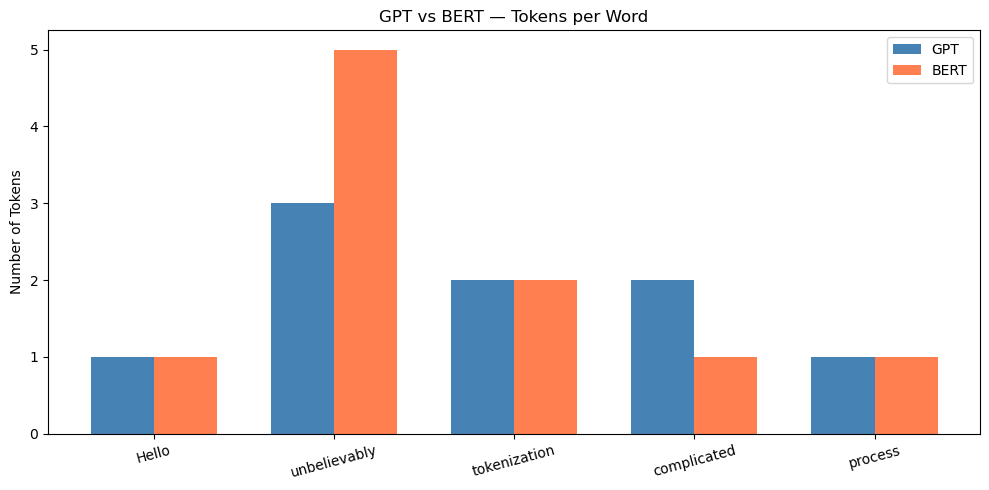

In [4]:
words = [
    "Hello",
    "unbelievably", 
    "tokenization",
    "complicated",
    "process"
]

gpt_counts  = []
bert_counts = []

for word in words:
    gpt_counts.append(len(gpt_enc.encode(word)))
    # BERT mein [CLS] aur [SEP] minus karo
    bert_count = len(bert_enc.encode(word)) - 2
    bert_counts.append(bert_count)

import numpy as np
x     = np.arange(len(words))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, gpt_counts,  width, label="GPT",  color="steelblue")
ax.bar(x + width/2, bert_counts, width, label="BERT", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(words, rotation=15)
ax.set_ylabel("Number of Tokens")
ax.set_title("GPT vs BERT — Tokens per Word")
ax.legend()

plt.tight_layout()
plt.show()

* GPT and BERT use **completely different tokenization methods**.

* In BERT (BERT), there are special tokens like **[CLS]** (for classification) and **[SEP]** (to separate sentences).

* BERT typically **converts text to lowercase**, while GPT does **not necessarily do this**.

* BERT tends to **break complex words into more subword pieces**, making it more granular.

* In BERT, **`##` indicates a continuation token**, meaning the subword is part of the previous word.
